# Matrix Factorisation on Movie Lens 1M dataset
Dataset from: [Movie Lens 1M Dataset](https://grouplens.org/datasets/movielens/1m/)

In [1]:
# Third-party
import numpy as np
from sklearn.metrics import explained_variance_score, mean_squared_error, mean_absolute_error, r2_score

# Local
from Dataset.ml1m_data_loader import load_and_merge_data, ml_test_train_split
from models.matrix_factorisation.NMF_matrix_factorisation import NMFMatrixFactorisation

### Load dataset

In [2]:
df = load_and_merge_data()
df_train, df_test = ml_test_train_split(df, test_proportion=0.2)

In [3]:
df_train.head()

,user_id,movie_id,rating,timestamp,title,genres
0,392,587,1,2000-12-08 19:43:44,Ghost (1990),Comedy|Romance|Thriller
1,1449,2053,1,2000-11-28 18:49:33,"Honey, I Blew Up the Kid (1992)",Children's|Comedy|Sci-Fi
2,2856,1290,3,2000-10-25 20:22:00,Some Kind of Wonderful (1987),Drama|Romance
3,808,2279,3,2000-11-28 06:39:46,Urban Legend (1998),Horror|Thriller
4,4480,2138,4,2000-07-31 06:32:45,Watership Down (1978),Animation|Children's|Drama|Fantasy


### Matrix Factorisation
Matrix factorisation algorithm applied to Top-N and Similarity (by movie) slates.

i.e. answers the questions: "what are the top N movies for a specific user" and "because someone watched a movie, they should watch"


Using:
- [SKLearn NMF (Non-Negative Matrix Factorisation)](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.NMF.html)]
- Similarity code from [here](https://github.com/dinesh-git17/movie_recommendation/tree/main)
- Top-N code from [here](https://medium.com/@quindaly/step-by-step-nmf-example-in-python-9974e38dc9f9)

In [4]:
NMF_model = NMFMatrixFactorisation(df_train, min_ratings=0, n_components=50)

### Evaluation metrics
Offline metrics - adapted from [here](https://github.com/aryan-jadon/Evaluation-Metrics-for-Recommendation-Systems/blob/main/recommenders/evaluation/python_evaluation.py)

Table from [here](https://github.com/recommenders-team/recommenders/blob/main/examples/03_evaluate/evaluation.ipynb)
|Metric|Range|Selection criteria|Limitation|Reference|
|------|-------------------------------|---------|----------|---------|
|RMSE|$> 0$|The smaller the better.|May be biased, and less explainable than MAE|[link](https://en.wikipedia.org/wiki/Root-mean-square_deviation)|
|MAE|$\geq 0$|The smaller the better.|Dependent on variable scale.|[link](https://en.wikipedia.org/wiki/Mean_absolute_error)|
|R2|$\leq 1$|The closer to $1$ the better.|Depend on variable distributions.|[link](https://en.wikipedia.org/wiki/Coefficient_of_determination)|
|Explained variance|$\leq 1$|The closer to $1$ the better.|Depend on variable distributions.|[link](https://en.wikipedia.org/wiki/Explained_variation)|

In [5]:
def evaluation_metrics(y_true, y_pred):
    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R Squared": r2_score(y_true, y_pred),
        "Explained variance": explained_variance_score(y_true, y_pred)
    }

In [6]:
# Extract predicted ratings for every movie in df_train
pred_ratings_train = []
for row in df_train.itertuples(index=False):
    pred_ratings_train.append(NMF_model.V.loc[row.user_id][row.title])

In [7]:
# Extract predicted ratings for every movie in df_test
pred_ratings_test = []
for row in df_test.itertuples(index=False):
    pred_ratings_test.append(NMF_model.V.loc[row.user_id][row.title])

In [8]:
print("Metrics on training data:")
[print(f"{k}: {v:.2f}") for k, v in evaluation_metrics(list(df_train.rating), pred_ratings_train).items()]
print("\nMetrics on test data:")
[print(f"{k}: {v:.2f}") for k, v in evaluation_metrics(list(df_test.rating), pred_ratings_test).items()]

Metrics on training data:
RMSE: 2.54
MAE: 2.24
R Squared: -4.18
Explained variance: -0.35

Metrics on test data:
RMSE: 2.76
MAE: 2.48
R Squared: -5.10
Explained variance: -0.26


[None, None, None, None]

### Apply model

In [9]:
recs = NMF_model.movie_similarity("101 Dalmatians (1961)")
recs

Rescuers, The (1977)              0.999389
Aristocats, The (1970)            0.999041
Three Caballeros, The (1945)      0.998768
Bambi (1942)                      0.998292
Fox and the Hound, The (1981)     0.997274
Sword in the Stone, The (1963)    0.997119
Oliver & Company (1988)           0.997047
All Dogs Go to Heaven (1989)      0.996407
Robin Hood (1973)                 0.996228
American Tail, An (1986)          0.996180
Name: 101 Dalmatians (1961), dtype: float64

In [10]:
recs = NMF_model.movie_similarity("101 Dalmatians (1996)")
recs

Homeward Bound II: Lost in San Francisco (1996)    0.990765
George of the Jungle (1997)                        0.986094
Parent Trap, The (1998)                            0.966587
Anastasia (1997)                                   0.955855
Homeward Bound: The Incredible Journey (1993)      0.953707
Madeline (1998)                                    0.948013
American Tail: Fievel Goes West, An (1991)         0.945087
Paulie (1998)                                      0.944268
Casper (1995)                                      0.941548
Tarzan (1999)                                      0.941175
Name: 101 Dalmatians (1996), dtype: float64

In [11]:
recs = NMF_model.movie_similarity("10 Things I Hate About You (1999)")
recs

She's All That (1999)         0.949237
Simply Irresistible (1999)    0.949040
Never Been Kissed (1999)      0.946938
Bachelor, The (1999)          0.934022
Random Hearts (1999)          0.924820
Story of Us, The (1999)       0.909752
Love Letter, The (1999)       0.898975
Mickey Blue Eyes (1999)       0.895375
Drive Me Crazy (1999)         0.893527
Runaway Bride (1999)          0.848550
Name: 10 Things I Hate About You (1999), dtype: float64

In [12]:
recs = NMF_model.movie_similarity("Young Guns (1988)")
recs

Rambo: First Blood Part II (1985)         0.990526
Iron Eagle II (1988)                      0.985025
Iron Eagle (1986)                         0.979768
Braddock: Missing in Action III (1988)    0.969616
Death Wish 4: The Crackdown (1987)        0.961202
Quick and the Dead, The (1995)            0.955094
Last Man Standing (1996)                  0.953669
Rambo III (1988)                          0.951977
Red Dawn (1984)                           0.948652
Aces: Iron Eagle III (1992)               0.945435
Name: Young Guns (1988), dtype: float64

Thoughts:
* Not recommending sequels
* Not using a test-train split -> this algorithm won't work if the requested movie doesn't exist in the pivot table
* Therefore, can't handle new movies or users

## Top-N movies for user

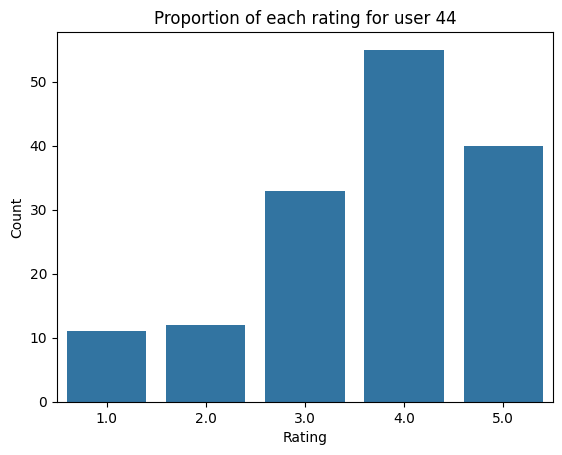

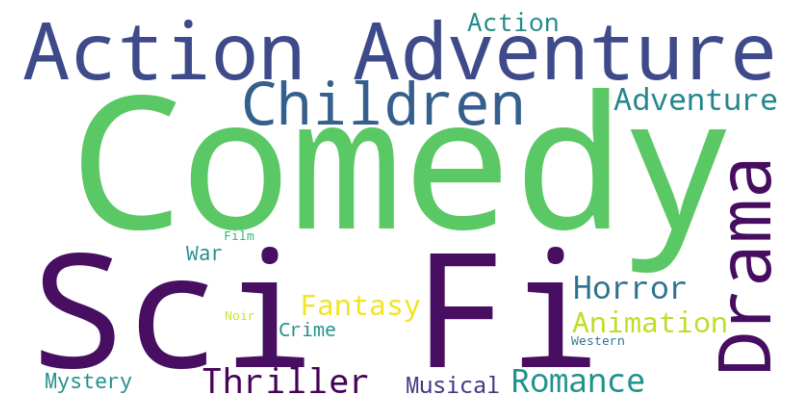

title
Star Wars: Episode IV - A New Hope (1977)                5.941164
Raiders of the Lost Ark (1981)                           5.762175
Wrong Trousers, The (1993)                               5.373028
Star Wars: Episode V - The Empire Strikes Back (1980)    5.294355
Princess Bride, The (1987)                               5.174604
                                                           ...   
Palookaville (1996)                                      0.000000
Donnie Brasco (1997)                                     0.000000
Impact (1949)                                            0.000000
American Beauty (1999)                                   0.000000
Sacco and Vanzetti (Sacco e Vanzetti) (1971)             0.000000
Name: 44, Length: 3706, dtype: float64
Recommendations for user 44:


,title,genres
0,"NeverEnding Story, The (1984)","[Adventure, Children's, Fantasy]"
1,Big (1988),"[Comedy, Fantasy]"
2,Terminator 2: Judgment Day (1991),"[Action, Sci-Fi, Thriller]"
3,"Goonies, The (1985)","[Adventure, Children's, Fantasy]"
4,Toy Story 2 (1999),"[Animation, Children's, Comedy]"
5,"Wizard of Oz, The (1939)","[Adventure, Children's, Drama, Musical]"
6,Wallace & Gromit: The Best of Aardman Animatio...,[Animation]
7,"Fugitive, The (1993)","[Action, Thriller]"
8,Monty Python's Life of Brian (1979),[Comedy]
9,"Christmas Story, A (1983)","[Comedy, Drama]"


In [13]:
user_id  = 44
NMF_model.understand_user_profile(user_id)
rec = NMF_model.user_top_N(user_id)
print(f"Recommendations for user 44:")
display(NMF_model.get_recommend_dataframe(rec))

## User profile evaluation

In [14]:
user_ids = [6013, 2195, 1198, 3662, 4713]

In [15]:
for user_id in user_ids:
    NMF_model.understand_user_profile(user_id, rating_dist=False, wc=False)
    rec = NMF_model.user_top_N(user_id)
    print(f"Recommendations for user {user_id}")
    display(NMF_model.get_recommend_dataframe(rec))

title
Shakespeare in Love (1998)                                 5.518281
Schindler's List (1993)                                    5.277585
Silence of the Lambs, The (1991)                           4.539320
Wrong Trousers, The (1993)                                 3.773905
Shawshank Redemption, The (1994)                           3.234070
                                                             ...   
Problem Child 2 (1991)                                     0.000000
Action Jackson (1988)                                      0.000000
Child's Play 3 (1992)                                      0.000000
Problem Child (1990)                                       0.000000
Tales from the Crypt Presents: Bordello of Blood (1996)    0.000000
Name: 6013, Length: 3706, dtype: float64
Recommendations for user 6013


,title,genres
0,West Side Story (1961),"[Musical, Romance]"
1,Chicken Run (2000),"[Animation, Children's, Comedy]"
2,Toy Story 2 (1999),"[Animation, Children's, Comedy]"
3,Casablanca (1942),"[Drama, Romance, War]"
4,"Grand Day Out, A (1992)","[Animation, Comedy]"
5,Gone with the Wind (1939),"[Drama, Romance, War]"
6,Fantasia (1940),"[Animation, Children's, Musical]"
7,"Bug's Life, A (1998)","[Animation, Children's, Comedy]"
8,Wallace & Gromit: The Best of Aardman Animatio...,[Animation]
9,Sense and Sensibility (1995),"[Drama, Romance]"


title
Star Wars: Episode IV - A New Hope (1977)      6.020886
Raiders of the Lost Ark (1981)                 5.153798
Star Trek: First Contact (1996)                5.042631
Sixth Sense, The (1999)                        4.617041
Matrix, The (1999)                             4.460526
                                                 ...   
My Man Godfrey (1957)                          0.000000
My Man Godfrey (1936)                          0.000000
Six of a Kind (1934)                           0.000000
My Life as a Dog (Mitt liv som hund) (1985)    0.000000
Hunger, The (1983)                             0.000000
Name: 2195, Length: 3706, dtype: float64
Recommendations for user 2195


,title,genres
0,Star Wars: Episode I - The Phantom Menace (1999),"[Action, Adventure, Fantasy, Sci-Fi]"
1,Star Trek IV: The Voyage Home (1986),"[Action, Adventure, Sci-Fi]"
2,Indiana Jones and the Temple of Doom (1984),"[Action, Adventure]"
3,Starship Troopers (1997),"[Action, Adventure, Sci-Fi, War]"
4,Twelve Monkeys (1995),"[Drama, Sci-Fi]"
5,E.T. the Extra-Terrestrial (1982),"[Children's, Drama, Fantasy, Sci-Fi]"
6,Jaws (1975),"[Action, Horror]"
7,Sneakers (1992),"[Crime, Drama, Sci-Fi]"
8,Ghostbusters (1984),"[Comedy, Horror]"
9,"X-Files: Fight the Future, The (1998)","[Mystery, Sci-Fi, Thriller]"


title
Gladiator (2000)                  6.062873
Saving Private Ryan (1998)        5.796314
Raiders of the Lost Ark (1981)    4.243599
Patriot, The (2000)               3.993024
X-Men (2000)                      3.814141
                                    ...   
Key Largo (1948)                  0.000000
Faithful (1996)                   0.000000
Face in the Crowd, A (1957)       0.000000
Everything Relative (1996)        0.000000
Nelly & Monsieur Arnaud (1995)    0.000000
Name: 1198, Length: 3706, dtype: float64
Recommendations for user 1198


,title,genres
0,X-Men (2000),"[Action, Sci-Fi]"
1,"Terminator, The (1984)","[Action, Sci-Fi, Thriller]"
2,Star Wars: Episode V - The Empire Strikes Back...,"[Action, Adventure, Drama, Sci-Fi, War]"
3,Frequency (2000),"[Drama, Thriller]"
4,Monty Python's Life of Brian (1979),[Comedy]
5,Gone in 60 Seconds (2000),"[Action, Crime]"
6,Jurassic Park (1993),"[Action, Adventure, Sci-Fi]"
7,Airplane! (1980),[Comedy]
8,"Shawshank Redemption, The (1994)",[Drama]
9,Indiana Jones and the Last Crusade (1989),"[Action, Adventure]"


title
Invasion of the Body Snatchers (1956)                         1.934124
War of the Worlds, The (1953)                                 1.905946
Day the Earth Stood Still, The (1951)                         1.777489
Planet of the Apes (1968)                                     1.624808
Thing, The (1982)                                             1.558213
                                                                ...   
Blood Spattered Bride, The (La Novia Ensangrentada) (1972)    0.000000
Primal Fear (1996)                                            0.000000
Prince Valiant (1997)                                         0.000000
Prince of Tides, The (1991)                                   0.000000
$1,000,000 Duck (1971)                                        0.000000
Name: 3662, Length: 3706, dtype: float64
Recommendations for user 3662


,title,genres
0,"Thing, The (1982)","[Action, Horror, Sci-Fi, Thriller]"
1,Escape from New York (1981),"[Action, Adventure, Sci-Fi, Thriller]"
2,"Fly, The (1986)","[Horror, Sci-Fi]"
3,Soylent Green (1973),"[Sci-Fi, Thriller]"
4,Westworld (1973),"[Action, Sci-Fi, Thriller, Western]"
5,Close Encounters of the Third Kind (1977),"[Drama, Sci-Fi]"
6,Logan's Run (1976),"[Action, Adventure, Sci-Fi]"
7,Mad Max 2 (a.k.a. The Road Warrior) (1981),"[Action, Sci-Fi]"
8,"Shining, The (1980)",[Horror]
9,"Exorcist, The (1973)",[Horror]


title
Sixth Sense, The (1999)                                 5.156816
Saving Private Ryan (1998)                              3.589137
Gladiator (2000)                                        3.345345
Godfather, The (1972)                                   2.233836
Patriot, The (2000)                                     2.226723
                                                          ...   
Six-String Samurai (1998)                               0.000000
Slappy and the Stinkers (1998)                          0.000000
Sleeper (1973)                                          0.000000
McCabe & Mrs. Miller (1971)                             0.000000
Black Cat, White Cat (Crna macka, beli macor) (1998)    0.000000
Name: 4713, Length: 3706, dtype: float64
Recommendations for user 4713


,title,genres
0,"Godfather, The (1972)","[Action, Crime, Drama]"
1,X-Men (2000),"[Action, Sci-Fi]"
2,Sleepless in Seattle (1993),"[Comedy, Romance]"
3,"Silence of the Lambs, The (1991)","[Drama, Thriller]"
4,Braveheart (1995),"[Action, Drama, War]"
5,Pretty Woman (1990),"[Comedy, Romance]"
6,"Perfect Storm, The (2000)","[Action, Adventure, Thriller]"
7,Titanic (1997),"[Drama, Romance]"
8,U-571 (2000),"[Action, Thriller]"
9,Notting Hill (1999),"[Comedy, Romance]"
